In [1]:
import json
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from scipy import signal
import numpy as np

from timescales.fit import PSD
from timescales.plts import set_default_rc
from ad_organoids.spectral import compute_spectra_windows

set_default_rc()

# 02. Computing and Fitting Spectra

This notebook computes spectra for the high dimensional MEA array. The results are saved out for futures processing. Maintaing the high dimensional structure allows us to flexibly combine spectra across wells / electrodes, removing recordings with high levels of noise.

In [2]:
# Paths
dirpath = '/home/rphammonds/projects/ad_organoids'
signal_path = f'{dirpath}/signals/plate4/plate4_midpoint_00'
meta_path = f'{dirpath}/data/plate4/meta.json'

# Load meta data
with open(meta_path) as json_file:
    meta = json.load(json_file)
    
# Unpack dict
fs = meta['fs'] * 1000
scale = meta['scale']
wells = meta['well_labels']

## Compute Spectra

Use Welch's method to compute spectra across 5s windows. Spectra ar computed using a 100th order autoregressive (AR) model. Since the frequency range of interest is limited to 0-1000 Hertz, the signals are downsampled from 12.5 kHz to 2 khz. This allows for faster AR coefficient solutions.

In [3]:
# Combine 2 npz files (1 second each) per window
n_windows = 2
out_dir = f'{dirpath}/spectra/plate4/plate4_midpoint_00/ar'

# Anonymous filter function (notch for 60 Hz line noise)
b, a = signal.iirnotch(60.0, 60.0, 2000)
filter_func = lambda x : signal.filtfilt(b, a, x)

# Compute spectra
freqs, powers = compute_spectra_windows(signal_path, fs, n_windows, ar_order=100, n_resample=2000,
                                        filter_func=filter_func, nfft=int(4096*2),
                                        n_jobs=-1, out_dir=out_dir, progress=tqdm)

# Take the mean across all electrodes per well
powers_mean_per_well = np.mean(powers, axis=(-3, -2))

  0%|          | 0/148 [00:00<?, ?it/s]

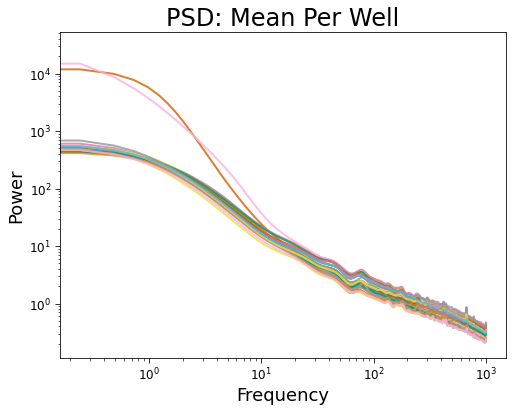

In [4]:
# Plot all wells, taking the mean across windows
plt.figure(figsize=(8, 6))

nrows = 5
ncols = 8

for i in range(nrows):
    for j in range(ncols):
        plt.loglog(freqs, powers_mean_per_well[:, i, j].mean(axis=0),
                   alpha=.8)
        
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.title('PSD: Mean Per Well');

## Fit

Fit the PSD using robust regression using a cauchy loss function and a double exponential knee model.

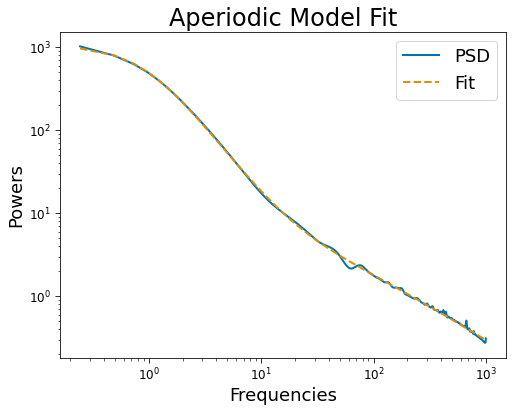

In [5]:
psd = PSD(freqs=freqs, powers=powers_mean_per_well.mean(axis=(0, 1, 2)))
psd.fit(ap_mode='double', method='cauchy', n_resample=1000)
psd.plot()